In [34]:
import polars as pl
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil
from datetime import datetime, timedelta 
import duckdb

pl.Config.set_tbl_cols(-1)          # show all columns
pl.Config.set_tbl_width_chars(300)  # increase table width
pl.Config.set_fmt_str_lengths(50)   # longer string display

con = duckdb.connect()
con.execute("SET memory_limit='3GB';")
con.execute("SET threads=2;")
con.execute("SET temp_directory='/work/data/tmp';")

In [40]:
def add_black_friday(ax=None, date=datetime(2025, 11, 28), label="Black Friday",
                    color="purple", days_offset=2):
    if ax is None:
        ax = plt.gca()

    ax.axvline(date, color=color, alpha=0.4, linewidth=2, linestyle="--")

    ymin, ymax = ax.get_ylim()

    ax.text(
        date - timedelta(days=days_offset),
        ymin,
        label,
        color=color,
        alpha=0.8,
        ha="right",
        va="bottom"
    )

# Layer 1 \- Data Quality

In [3]:
PATH_PARQUETS = "/work/data/parquets"

In [4]:
fact_sales = pl.scan_parquet(os.path.join(PATH_PARQUETS, "fact_sales_v2.parquet"))
fact_campaign_sales = pl.scan_parquet(os.path.join(PATH_PARQUETS, "fact_campaign_sales_v2.parquet"))
fact_points = pl.scan_parquet(os.path.join(PATH_PARQUETS, "fact_points_v2.parquet"))

dim_store = pl.scan_parquet(os.path.join(PATH_PARQUETS, "dim_store_v2.parquet"))
dim_product = pl.scan_parquet(os.path.join(PATH_PARQUETS, "dim_product_v2.parquet"))
dim_campaign = pl.scan_parquet(os.path.join(PATH_PARQUETS, "dim_campaign_v2.parquet"))
dim_member = pl.scan_parquet(os.path.join(PATH_PARQUETS, "dim_member_v2.parquet"))

fact_web_sessions = pl.scan_parquet(os.path.join(PATH_PARQUETS, "fact_web_sessions_v2.parquet"))

In [4]:
# PARQUET EDA (POLARS)

# ==========================================================
# HISTOGRAM (NULL-SAFE, REAL BIN CENTERS)
# ==========================================================
def histogram_polars(lf: pl.LazyFrame, col: str, bins: int = 50):

    lf_non_null = lf.filter(pl.col(col).is_not_null())

    min_max = (
        lf_non_null.select([
            pl.col(col).min().alias("min"),
            pl.col(col).max().alias("max")
        ])
        .collect()
    )

    if min_max.height == 0:
        return None, None, None

    min_val = min_max["min"][0]
    max_val = min_max["max"][0]

    if min_val is None or max_val is None or min_val == max_val:
        return None, None, None

    bin_width = (max_val - min_val) / bins

    hist = (
        lf_non_null
        .with_columns(
            (
                ((pl.col(col) - min_val) / bin_width)
                .floor()
                .clip(0, bins - 1)
                .cast(pl.Int32)
                .alias("bin")
            )
        )
        .group_by("bin")
        .agg(pl.len().alias("count"))
        .sort("bin")
        .collect()
    )

    # Compute actual bin centers
    hist = hist.with_columns(
        (
            min_val + (pl.col("bin") + 0.5) * bin_width
        ).alias("bin_center")
    )

    return hist, bin_width, (min_val, max_val)


# ==========================================================
# FULL EDA
# ==========================================================
def run_eda_polars(lf: pl.LazyFrame, df_name="dataframe", use_cache=False):
    if use_cache:
        lf = lf.cache()

    print(f"\n{'='*60}")
    print(f"EDA for: {df_name}")
    print(f"{'='*60}\n")

    schema = lf.collect_schema()

    total_rows = lf.select(pl.len()).collect().item()
    print("Total rows:", total_rows)

    numeric_cols = [
        c for c, t in schema.items()
        if t in (
            pl.Int8, pl.Int16, pl.Int32, pl.Int64,
            pl.Float32, pl.Float64
        )
    ]

    categorical_cols = [c for c, t in schema.items() if t == pl.Utf8]
    date_cols = [c for c, t in schema.items() if t in (pl.Date, pl.Datetime)]

    # ======================================================
    # NUMERIC STATS
    # ======================================================
    for col in numeric_cols:
        print(f"\n--- Numeric column: {col} ---")

        stats = (
            lf.select([
                pl.col(col).count().alias("count"),
                pl.col(col).null_count().alias("null_count"),
                pl.col(col).mean().alias("mean"),
                pl.col(col).median().alias("median"),
                pl.col(col).std().alias("std"),
                pl.col(col).min().alias("min"),
                pl.col(col).max().alias("max"),
                pl.col(col).quantile(0.25).alias("q1"),
                pl.col(col).quantile(0.75).alias("q3"),
                pl.col(col).skew().alias("skew"),
            ])
            .collect()
        )

        print(stats)

        null_count = int(stats["null_count"][0])
        missing_pct = null_count / total_rows if total_rows else 0
        print(f"Missing %: {missing_pct:.4%}")

        zero_count = (
            lf.filter(pl.col(col).is_not_null() & (pl.col(col) == 0))
            .select(pl.len())
            .collect()
            .item()
        )
        zero_pct = zero_count / total_rows if total_rows else 0
        print(f"Zero values: {zero_count} ({zero_pct:.4%})")


        q1 = stats["q1"][0]
        q3 = stats["q3"][0]

        if q1 is not None and q3 is not None and q3 >= q1:
            iqr = q3 - q1
            if iqr == 0:
                print("IQR outliers: N/A (IQR=0)")
            else:
                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr

                outliers = (
                    lf.filter(
                        pl.col(col).is_not_null() &
                        ((pl.col(col) < lower) | (pl.col(col) > upper))
                    )
                    .select(pl.len())
                    .collect()
                    .item()
                )

                print("IQR outliers:", outliers)
        else:
            print("IQR outliers: N/A (insufficient data)")

    # ======================================================
    # CATEGORICAL STATS
    # ======================================================
    for col in categorical_cols:
        print(f"\n--- Categorical column: {col} ---")

        unique_count = (
            lf.select(pl.col(col).n_unique())
              .collect()
              .item()
        )

        null_count = (
            lf.select(pl.col(col).null_count())
              .collect()
              .item()
        )

        print("Unique values:", unique_count)
        print("Null values:", null_count)

        if unique_count > 1000:
            print("High cardinality feature -> consider cleaning/encoding")

        missing_pct = null_count / total_rows if total_rows else 0
        print(f"Missing %: {missing_pct:.4%}")

        top = (
            lf.filter(pl.col(col).is_not_null())
              .group_by(col)
              .agg(pl.len().alias("count"))
              .sort("count", descending=True)
              .limit(10)
              .collect()
        )

        print("Top 10 (non-null):")
        print(top)

    # ======================================================
    # DATE STATS
    # ======================================================
    for col in date_cols:
        print(f"\n--- Date column: {col} ---")

        date_stats = (
            lf.select([
                pl.col(col).min().alias("min"),
                pl.col(col).max().alias("max"),
                pl.col(col).null_count().alias("null_count"),
            ])
            .collect()
        )

        print(date_stats)

        null_count = int(date_stats["null_count"][0])
        missing_pct = null_count / total_rows if total_rows else 0
        print(f"Missing %: {missing_pct:.4%}")

    # ======================================================
    # PLOTTING (REAL VALUE X-AXIS + LOG SCALE)
    # ======================================================
    if numeric_cols or categorical_cols:

        total_plots = len(numeric_cols) + len(categorical_cols)
        cols = 3
        rows = ceil(total_plots / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
        axes = axes.flatten()

        idx = 0
        MAX_LABEL_LENGTH = 60

        # ----------------------------
        # Numeric Histograms
        # ----------------------------
        for col in numeric_cols:

            hist, bin_width, min_max = histogram_polars(lf, col, bins=50)

            if hist is not None and hist.height > 0:
                axes[idx].bar(
                    hist["bin_center"].to_numpy(),
                    hist["count"].to_numpy(),
                    width=bin_width
                )

                # LOG SCALE FIX
                axes[idx].set_yscale("log")

                axes[idx].set_title(col)
                axes[idx].set_xlabel("Value")
                axes[idx].set_ylabel("Count (log scale)")
            else:
                axes[idx].set_title(f"{col} (constant / null)")

            idx += 1


        # ----------------------------
        # Categorical Top 10
        # ----------------------------
        for col in categorical_cols:

            top = (
                lf.filter(pl.col(col).is_not_null())
                .group_by(col)
                .agg(pl.len().alias("count"))
                .sort("count", descending=True)
                .limit(10)
                .collect()
            )

            if top.height > 0:

                labels = [
                    str(v)[:MAX_LABEL_LENGTH] + "…" if len(str(v)) > MAX_LABEL_LENGTH else str(v)
                    for v in top[col].to_list()
                ]

                axes[idx].barh(
                    labels,
                    top["count"].to_list()
                )

                axes[idx].set_title(f"{col} (top 10)")
                axes[idx].set_xlabel("Count")
            else:
                axes[idx].set_title(f"{col} (all null)")

            idx += 1

        # Remove unused axes
        for i in range(idx, len(axes)):
            fig.delaxes(axes[i])

        plt.tight_layout()
        plt.show()

In [5]:
# PARQUET EDA (DUCKDB)

# ==========================================================
# MAIN EDA FUNCTION
# ==========================================================
def run_eda_duckdb(parquet_path, table_name="table", bins=50):

    total_rows = con.execute("""
    SELECT COUNT(*)
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    """).fetchone()[0]

    print("Total rows:", total_rows)

    print("\n" + "="*60)
    print(f"EDA for: {table_name}")
    print("="*60 + "\n")

    # ------------------------------------------------------
    # GET SCHEMA
    # ------------------------------------------------------
    schema = con.execute(
        f"DESCRIBE SELECT * FROM '{parquet_path}'"
    ).fetch_df()

    numeric_cols = schema[
        schema["column_type"].str.contains(
            "INT|DOUBLE|FLOAT|DECIMAL", case=False
        )
    ]["column_name"].tolist()

    categorical_cols = schema[
        schema["column_type"].str.contains("VARCHAR", case=False)
    ]["column_name"].tolist()

    date_cols = schema[
        schema["column_type"].str.contains("DATE|TIMESTAMP", case=False)
    ]["column_name"].tolist()

    # ======================================================
    # NUMERIC STATS
    # ======================================================
    for col in numeric_cols:

        print(f"\n--- Numeric column: {col} ---")

        stats_query = f"""
        SELECT
            COUNT({col}) AS count,
            SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS null_count,
            AVG({col}) AS mean,
            MEDIAN({col}) AS median,
            STDDEV({col}) AS std,
            MIN({col}) AS min,
            MAX({col}) AS max,
            QUANTILE_CONT({col}, 0.25) AS q1,
            QUANTILE_CONT({col}, 0.75) AS q3,
            SKEWNESS({col}) AS skew
        FROM '{parquet_path}'
        """

        stats = con.execute(stats_query).fetch_df()
        print(stats)

        missing_pct = stats["null_count"][0] / total_rows if total_rows else 0
        print(f"Missing %: {missing_pct:.4%}")

        zero_count = con.execute(f"""
        SELECT COUNT(*)
        FROM '{parquet_path}'
        WHERE {col} IS NOT NULL AND {col} = 0
        """).fetchone()[0]

        zero_pct = zero_count / total_rows if total_rows else 0
        print(f"Zero values: {zero_count} ({zero_pct:.4%})")

        # IQR outliers
        q1 = stats["q1"][0]
        q3 = stats["q3"][0]

        if q1 is not None and q3 is not None:
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            outlier_query = f"""
            SELECT COUNT(*) AS outliers
            FROM '{parquet_path}'
            WHERE {col} IS NOT NULL
              AND ({col} < {lower} OR {col} > {upper})
            """

            outliers = con.execute(outlier_query).fetchone()[0]
            print("IQR outliers:", outliers)
        else:
            print("IQR outliers: N/A")

    # ======================================================
    # CATEGORICAL STATS
    # ======================================================
    for col in categorical_cols:

        print(f"\n--- Categorical column: {col} ---")

        unique_query = f"""
        SELECT
            COUNT(DISTINCT {col}) AS unique_values,
            SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS null_count
        FROM '{parquet_path}'
        """

        stats = con.execute(unique_query).fetch_df()
        print(stats)

        missing_pct = stats["null_count"][0] / total_rows if total_rows else 0
        print(f"Missing %: {missing_pct:.4%}")

        top_query = f"""
        SELECT {col}, COUNT(*) AS count
        FROM '{parquet_path}'
        WHERE {col} IS NOT NULL
        GROUP BY {col}
        ORDER BY count DESC
        LIMIT 10
        """

        top = con.execute(top_query).fetch_df()
        print("Top 10:")
        print(top)

    # ======================================================
    # DATE STATS
    # ======================================================
    for col in date_cols:

        print(f"\n--- Date column: {col} ---")

        date_query = f"""
        SELECT
            MIN({col}) AS min,
            MAX({col}) AS max,
            SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS null_count
        FROM '{parquet_path}'
        """

        stats = con.execute(date_query).fetch_df()
        print(stats)

        missing_pct = stats["null_count"][0] / total_rows if total_rows else 0
        print(f"Missing %: {missing_pct:.4%}")

    # ======================================================
    # PLOTTING
    # ======================================================
    total_plots = len(numeric_cols) + len(categorical_cols)
    if total_plots == 0:
        return

    cols = 3
    rows = ceil(total_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten()
    idx = 0

    # ----------------------------
    # Numeric Histograms
    # ----------------------------
    for col in numeric_cols:

        hist_query = f"""
        WITH stats AS (
            SELECT
                MIN({col}) AS min_val,
                MAX({col}) AS max_val
            FROM '{parquet_path}'
            WHERE {col} IS NOT NULL
        ),
        binned AS (
            SELECT
                FLOOR(
                    ({col} - stats.min_val) /
                    NULLIF((stats.max_val - stats.min_val) / {bins}, 0)
                ) AS bin
            FROM '{parquet_path}', stats
            WHERE {col} IS NOT NULL
        )
        SELECT bin, COUNT(*) AS count
        FROM binned
        GROUP BY bin
        ORDER BY bin
        """

        hist = con.execute(hist_query).fetch_df()

        if len(hist) > 0:
            axes[idx].bar(hist["bin"], hist["count"])
            axes[idx].set_yscale("log")
            axes[idx].set_title(col)
            axes[idx].set_xlabel("Bin")
            axes[idx].set_ylabel("Count (log)")
        else:
            axes[idx].set_title(f"{col} (constant/null)")

        idx += 1

    # ----------------------------
    # Categorical Top 10
    # ----------------------------
    for col in categorical_cols:

        top_query = f"""
        SELECT {col}, COUNT(*) AS count
        FROM '{parquet_path}'
        WHERE {col} IS NOT NULL
        GROUP BY {col}
        ORDER BY count DESC
        LIMIT 10
        """

        top = con.execute(top_query).fetch_df()

        if len(top) > 0:
            axes[idx].barh(top[col], top["count"])
            axes[idx].set_title(f"{col} (top 10)")
            axes[idx].set_xlabel("Count")
        else:
            axes[idx].set_title(f"{col} (all null)")

        idx += 1

    # Remove unused axes
    for i in range(idx, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

## Fact: Sales

In [6]:
df_preview = fact_sales.fetch(15_000).to_pandas()
df_preview

### Null values

In [7]:
fact_sales.select(pl.all().null_count()).collect()

### EDA

In [8]:
run_eda_polars(fact_sales, "fact_sales")

The exploratory data analysis of the fact\_sales table, consisting of 12,954,168 observations, provides insight into both the distribution of transaction variables and potential data quality issues\. The numeric variable product\_quantity shows a highly concentrated distribution with a median and interquartile range of 1, indicating that most transactions involve the purchase of a single product\. The mean quantity \(0\.96\) is slightly lower due to the presence of zero and negative values, with a minimum of −99 and approximately 5\.35% of observations equal to zero, likely representing returns, cancellations, or correction entries\. The revenue variable exhibits a strongly dispersed distribution with a median of 82\.46 and a mean of 116\.81, reflecting the presence of large outliers and extreme values ranging from −2\.47 million to 2\.47 million\. These extreme values likely correspond to bulk transactions or accounting adjustments such as refunds\. Similarly, the discount variable is highly right\-skewed \(skew = 8\.04\), with a median discount of 4\.99 but a much higher mean of 27\.50, indicating that while many purchases involve small or no discounts, a smaller number of transactions receive very large promotional reductions\. Approximately 46\.2% of observations contain no discount\.

Among the categorical variables, matas\_id represents individual customers and contains 573,421 unique values, indicating a large customer base and confirming its role as a high\-cardinality identifier\. The transaction\_id variable similarly exhibits very high cardinality with over 5\.27 million unique values, consistent with transaction\-level records\. The product\_id variable contains 66,748 unique products, reflecting the breadth of the product catalog\. The store\_id variable includes 266 unique stores, with a notable concentration of transactions in store 28000, which accounts for a large share of observations and likely represents the online store\. This pattern is further supported by the channel variable, which indicates that the majority of transactions occur in physical stores \(9\.4 million\) compared to web transactions \(3\.5 million\)\. The variables order\_id and order\_delivery\_method contain a substantial proportion of missing values \(72\.66%\), suggesting that these fields are only populated for web purchases and not for in\-store transactions\. Finally, the sales\_date variable spans from December 19, 2024 to December 18, 2025, indicating that the dataset covers approximately one year of transactional activity without missing values\. Overall, the exploratory analysis reveals a dataset with realistic retail transaction characteristics, including highly skewed monetary variables, high\-cardinality identifiers, and structural missingness associated with online order information\.

## Fact: Campaign sales

In [9]:
df_preview = fact_campaign_sales.fetch(15_000).to_pandas()
df_preview

### Null values

In [10]:
fact_campaign_sales.select(pl.all().null_count()).collect()

### EDA

In [11]:
run_eda_polars(fact_campaign_sales, "campaign_sales")

The exploratory analysis of the fact\_campaign\_sales dataset, which contains 3,303,172 observations, provides insight into transactions associated with marketing campaigns\. The numeric variable revenue displays a strongly right\-skewed distribution \(skew = 8\.15\), with a median value of 112\.47 and a higher mean of 163\.03, indicating the presence of large transaction values\. The dataset contains extreme values ranging from −2,600 to 41,734\.87, suggesting the presence of returns, corrections, or unusually large purchases\. Approximately 10\.7% of observations have zero revenue, which may reflect promotional transactions or data adjustments\. The product\_quantity variable shows a highly concentrated distribution similar to the main sales table, with a median and interquartile range of 1, indicating that most campaign transactions involve the purchase of a single product\. The mean quantity is slightly higher at 1\.16, while negative values \(minimum = −6\) likely represent product returns\.

Among the categorical variables, campaign\_id contains 511 unique campaigns, indicating a diverse set of promotional initiatives\. The matas\_id variable represents individual customers and exhibits high cardinality with 438,076 unique identifiers, reflecting a large customer base participating in campaign\-related purchases\. Similarly, transaction\_id \(1,625,772 unique values\) and product\_id \(53,088 unique values\) represent transaction\-level and product\-level identifiers, both displaying high cardinality as expected in a transactional dataset\. The store\_id variable includes 267 unique stores, with store 28000 accounting for a substantial portion of transactions, likely representing the online store\. The channel variable shows an almost even distribution between web \(1\.64 million\) and store transactions \(1\.66 million\), suggesting that campaign\-related purchases are relatively balanced across online and physical channels\. Finally, the sales\_date variable ranges from December 20, 2024 to December 17, 2025 with no missing values, indicating that the dataset covers approximately one year of campaign\-driven sales activity\. Overall, the exploratory analysis reveals realistic retail patterns with highly skewed revenue distributions, high\-cardinality identifiers, and transaction characteristics consistent with promotional purchase behavior\.

## Fact: Points

In [12]:
df_preview = fact_points.fetch(15_000).to_pandas()
df_preview

### Null values

In [13]:
fact_points.select(pl.all().null_count()).collect()

### EDA

In [14]:
run_eda_polars(fact_points, "points")

The exploratory analysis of the fact\_points dataset, containing 8,206,919 observations, provides insight into customer loyalty program activity\. The numeric variable points represents the number of loyalty points earned or redeemed in each transaction\. The distribution shows a median of 17 points and an interquartile range between 3 and 47 points, indicating that most loyalty transactions involve relatively small point amounts\. However, the distribution exhibits substantial dispersion, with extreme values ranging from −111,735 to 111,735 and a very large standard deviation \(756\.9\), suggesting the presence of large point adjustments or aggregated transactions\. Approximately 4\.88% of observations contain zero points, while a large number of observations are identified as IQR outliers, reflecting the highly skewed and heavy\-tailed nature of loyalty point transactions\.

The categorical variable matas\_id, representing individual customers, contains 573,124 unique identifiers, indicating a broad customer base and confirming its role as a high\-cardinality identifier within the dataset\. The variable point\_type distinguishes between points earned and points redeemed, with the majority of transactions corresponding to earned points \(7\.4 million observations\) and a smaller share representing redeemed points \(approximately 802 thousand\)\. Finally, the point\_date variable spans from December 19, 2024 to December 18, 2025 with no missing values, indicating that the loyalty activity dataset covers approximately one year of customer engagement with the loyalty program\. Overall, the dataset reflects typical loyalty program dynamics, where most transactions involve small point accruals while a smaller number of large point adjustments generate extreme values in the distribution\.

## Dim: Store

In [15]:
df_preview = dim_store.fetch(15_000).to_pandas()
df_preview

### Null values

In [16]:
dim_store.select(pl.all().null_count()).collect()

### EDA

In [17]:
run_eda_polars(dim_store, "dim_store")

The exploratory analysis of the dim\_store dataset provides descriptive information about the physical and online retail locations included in the transaction data\. The table contains 266 unique store records, each representing a distinct retail location or sales channel\. The variables store\_id and store\_name both contain 266 unique values with no missing observations, confirming that each store entry corresponds to a unique identifier and location name\. The store\_zip\_code variable includes 194 unique postal codes, indicating that some geographic areas contain multiple stores\. The most frequent zip codes correspond to major Danish urban areas such as Copenhagen \(e\.g\., 2300 and 2000\) and Aalborg \(9000\), suggesting a higher store density in large cities\. The store\_region variable groups stores into six geographic categories, with the Hovedstaden region containing the largest number of stores \(93\), followed by Syddanmark \(53\) and Midtjylland \(50\)\. Smaller store counts are observed in Sjælland and Nordjylland, while a single observation corresponds to Webshoppen, representing the online channel\. Overall, the dataset appears complete with no missing values and provides a clear geographic structure that can be used to analyze regional sales patterns and channel differences between physical stores and online transactions\.

## Dim: Product

In [18]:
df_preview = dim_product.fetch(15_000).to_pandas()
df_preview

### Null values

In [19]:
dim_product.select(pl.all().null_count()).collect()

### EDA

In [20]:
run_eda_polars(dim_product, "dim_product")

The exploratory analysis of the dim\_product dataset describes the product assortment available in the retail system and contains 66,748 unique products\. The numeric variable contents\_quantity, representing the size or quantity of product contents, has a median value of 10 units and a wide range extending up to 8,800 units, indicating substantial variation in product packaging sizes\. The distribution is highly right\-skewed, with a mean of 70\.8 and many identified outliers, suggesting the presence of unusually large package sizes or bundled products\. Similarly, the sales\_price variable exhibits strong right\-skewness, with a median price of approximately 194\.95 and a maximum value of 17,999, indicating that most products fall within a moderate price range while a small number of premium products drive the upper tail of the distribution\. Only a small proportion of observations contain missing values \(0\.30%\) or zero prices \(1\.84%\), suggesting overall good data completeness\.

The categorical variables provide a hierarchical classification of the product assortment\. The product\_id variable uniquely identifies each product, while product\_name and brand\_name exhibit high cardinality due to the large number of distinct items and brands in the assortment\. Among brands, major cosmetic brands such as MAC, DIOR, CHANEL, and Lancôme appear frequently, reflecting the retailer’s focus on beauty and skincare products\. The product hierarchy is structured across several categorical levels, including category, sub\_category, segment, and sub\_segment, which organize products into increasingly granular groupings\. The most represented categories include Makeup, Hudpleje \(skincare\), and Hårpleje og styling \(haircare\), indicating that beauty and personal care products dominate the assortment\. At more detailed levels, segments such as Cremer, Parfume, and Foundation and sub\-segments such as Læbestift, Eau de Parfum, and Flydende foundation appear most frequently\. The variable contents\_unit contains 29 unique units, primarily milliliters, pieces, and grams, although inconsistent capitalization suggests minor data standardization issues\. Finally, the attributes variable contains descriptive product tags such as “Vegansk” or “Uden parabener,” but exhibits a high proportion of missing values \(approximately 70%\), indicating that product attributes are only recorded for a subset of products\. Overall, the dataset provides a detailed hierarchical structure for analyzing product assortment and category\-level sales performance\.

## Dim: Campaign

In [21]:
df_preview = dim_campaign.fetch(15_000).to_pandas()
df_preview

### Null values

In [22]:
dim_campaign.select(pl.all().null_count()).collect()

### EDA

In [23]:
run_eda_polars(dim_campaign, "dim_campaign")

The exploratory analysis of the dim\_campaign dataset provides an overview of the marketing campaigns included in the transactional data and contains 511 campaign records, each representing a unique promotional initiative\. The variable campaign\_id uniquely identifies each campaign and contains no missing values, confirming that every campaign is represented by a distinct identifier\. The campaign\_name variable includes 424 unique values, indicating that some campaigns are reused or repeated across different time periods or promotional contexts\. Many campaign names explicitly reference promotional discounts such as “Spar 20%” or “3 for 2,” suggesting that percentage discounts and bundle offers are common promotional mechanisms\.

The variable campaign\_type classifies campaigns into five categories, with Tilbudsbev representing the majority of campaigns \(281\), followed by Club campaigns \(163\), while MatasPlus, ClubMaaned, and Sær kamp represent smaller subsets\. This distribution indicates that general promotional campaigns and loyalty club promotions dominate the campaign portfolio\. The variable campaign\_primary\_categories identifies the product categories targeted by each campaign\. The most frequently targeted categories include Hudpleje \(skincare\) and Makeup, followed by Hårpleje og styling, Helsekost, and Træning og ernæring, suggesting that campaigns primarily focus on beauty and personal care products, which aligns with the retailer’s core assortment\. The discounts variable contains detailed information about the specific promotional offers associated with each campaign, stored as structured text describing discount identifiers and names\. Each campaign contains a unique discount configuration, resulting in 511 distinct discount records\.

Finally, the temporal variables campaign\_start\_date and campaign\_end\_date define the active period of each campaign\. The campaigns span from December 20, 2024 to December 16, 2025, although the maximum campaign end date extends to December 31, 2030, suggesting that some campaigns may represent placeholder end dates or long\-term promotional structures\. Overall, the dataset provides structured information on promotional activities, including campaign types, targeted product categories, and campaign timing, which enables the analysis of how marketing campaigns influence sales and customer purchasing behavior\.

## Dim: Member

In [24]:
df_preview = dim_member.fetch(15_000).to_pandas()
df_preview

### Null values

In [25]:
dim_member.select(pl.all().null_count()).collect()

### EDA

In [26]:
run_eda_polars(dim_member, "dim_member")

The exploratory analysis of the dim\_member dataset provides a member\-level view of customer demographics, engagement, and spending behavior for 573,421 loyalty program members, with sales\-related variables restricted to the same one\-year period as the fact\_sales and fact\_campaign\_sales tables\. The demographic variables indicate that the customer base is predominantly female \(495,086 members\), with smaller groups of male and neutral\-gender members, and a median age of 47 years\. However, the age variable also contains implausible values, ranging from 0 to 985, indicating a limited number of erroneous observations that should be treated as data quality issues\. The categorical age groups appear substantially more realistic, with the largest segments concentrated in 18–29, 30s, 40s, and 50s, indicating a broad but mature customer base\. Regionally, members are concentrated in Hovedstaden, followed by Midtjylland and Syddanmark, while Ukendt captures a smaller group of customers with unknown location\. The customer\_type variable shows that most members are either Omni\-channel or store\-oriented, while purely web\-based customers represent a smaller subset\.

The behavioral and transactional variables reveal strong right\-skewness across most member\-level measures\. Total annual sales average 2,685\.67 DKK with a median of 1,709\.15 DKK, while total transactions average 9\.0 per member and median basket size is 257\.86 DKK, indicating substantial heterogeneity in customer value\. Store\-based activity dominates web\-based activity: average store\_sales\_kr exceeds web\_sales\_kr, and only 7\.38% of members record zero store purchases, compared with 44\.69% recording zero web purchases, suggesting that a large share of members remain store\-only shoppers\. Campaign\-related spending is also highly skewed, with average campaign\_sales\_kr of 1,083\.12 DKK but large dispersion and extreme upper\-tail values, indicating that campaign responsiveness varies substantially across members\. Loyalty points are similarly concentrated among a smaller group of highly active customers, with a median of 156 but a maximum above 177,000, reflecting a heavy\-tailed distribution\. Email engagement variables show that while emails are widely distributed, interaction declines across the funnel: around 18\.5% of members received no emails, 28\.0% opened none, and 56\.3% clicked none, suggesting that email exposure is broad but deeper engagement is much more limited\. The my\_brands variable has high cardinality and substantial missingness \(38\.5%\), indicating that preferred\-brand information is available only for a subset of members\. Likewise, last\_email\_open, store\_last\_purchase, and particularly web\_last\_purchase contain structurally meaningful missing values, reflecting members with no recent activity in those specific channels\. Overall, the dim\_member table provides a rich customer\-level profile combining demographics, channel behavior, purchase intensity, campaign responsiveness, and loyalty engagement, while also highlighting a small number of age anomalies and several variables with structurally informative missingness\.

## Fact: Web sessions

### Null values \+ EDA

In [27]:
# Here we query data with duckdb instead of polars, since the dataset is too large for the available RAM. 

run_eda_duckdb(
    "/work/data/parquets/fact_web_sessions_v2.parquet",
    "fact_web_sessions_v2"
)

# Layer 2 \- Dataset Level Diagnostics 

For Layer 2: dataset\-level diagnostics, the goal is to check:
\- candidate key integrity
\- key nulls
\- duplicate key rows
\- referential integrity / join coverage across tables

Purpose: we are trying to figure out if the tables actually connect correctly 

In [28]:
import duckdb
import pandas as pd

PATH_PARQUETS = "/work/data/parquets"

paths = {
    "fact_sales": f"{PATH_PARQUETS}/fact_sales_v2.parquet",
    "fact_campaign_sales": f"{PATH_PARQUETS}/fact_campaign_sales_v2.parquet",
    "fact_points": f"{PATH_PARQUETS}/fact_points_v2.parquet",
    "dim_store": f"{PATH_PARQUETS}/dim_store_v2.parquet",
    "dim_product": f"{PATH_PARQUETS}/dim_product_v2.parquet",
    "dim_campaign": f"{PATH_PARQUETS}/dim_campaign_v2.parquet",
    "dim_member": f"{PATH_PARQUETS}/dim_member_v2.parquet",
    "fact_web_sessions": f"{PATH_PARQUETS}/fact_web_sessions_v2.parquet",
}

con = duckdb.connect()

In [29]:
def check_key_duckdb(parquet_path: str, table_name: str, key_cols: list[str]) -> pd.DataFrame:
    key_expr = ", ".join(key_cols)
    null_condition = " OR ".join([f"{c} IS NULL" for c in key_cols])

    query = f"""
    WITH grouped AS (
        SELECT
            {key_expr},
            COUNT(*) AS cnt
        FROM '{parquet_path}'
        GROUP BY {key_expr}
    )
    SELECT
        '{table_name}' AS table_name,
        '{", ".join(key_cols)}' AS key_tested,
        (SELECT COUNT(*) FROM '{parquet_path}') AS total_rows,
        (SELECT COUNT(*) FROM '{parquet_path}' WHERE {null_condition}) AS null_key_rows,
        (SELECT COUNT(*) FROM grouped) AS distinct_key_combinations,
        (SELECT COUNT(*) FROM grouped WHERE cnt > 1) AS duplicate_key_groups,
        (SELECT COALESCE(SUM(cnt), 0) FROM grouped WHERE cnt > 1) AS rows_in_duplicate_groups
    """
    return con.execute(query).fetch_df()

In [30]:
def check_fk_duckdb(
    fact_path: str,
    dim_path: str,
    fact_table: str,
    dim_table: str,
    fact_key: str,
    dim_key: str
) -> pd.DataFrame:

    query = f"""
    SELECT
        '{fact_table}' AS fact_table,
        '{dim_table}' AS dim_table,
        '{fact_key}' AS fact_key,
        '{dim_key}' AS dim_key,
        COUNT(*) AS total_fact_rows,
        COUNT(*) FILTER (WHERE f.{fact_key} IS NULL) AS null_fk_rows,
        COUNT(*) FILTER (WHERE f.{fact_key} IS NOT NULL AND d.{dim_key} IS NOT NULL) AS matched_rows,
        COUNT(*) FILTER (WHERE f.{fact_key} IS NOT NULL AND d.{dim_key} IS NULL) AS unmatched_rows
    FROM '{fact_path}' f
    LEFT JOIN '{dim_path}' d
      ON f.{fact_key} = d.{dim_key}
    """
    return con.execute(query).fetch_df()

In [31]:
def check_id_profile_duckdb(parquet_path: str, table_name: str, id_col: str) -> pd.DataFrame:
    query = f"""
    WITH grouped AS (
        SELECT
            {id_col},
            COUNT(*) AS cnt
        FROM '{parquet_path}'
        WHERE {id_col} IS NOT NULL
        GROUP BY {id_col}
    )
    SELECT
        '{table_name}' AS table_name,
        '{id_col}' AS id_column,
        (SELECT COUNT(*) FROM '{parquet_path}') AS total_rows,
        (SELECT COUNT(*) FROM '{parquet_path}' WHERE {id_col} IS NULL) AS null_id_rows,
        (SELECT COUNT(DISTINCT {id_col}) FROM '{parquet_path}' WHERE {id_col} IS NOT NULL) AS distinct_ids,
        (SELECT MIN(cnt) FROM grouped) AS min_rows_per_id,
        (SELECT AVG(cnt) FROM grouped) AS avg_rows_per_id,
        (SELECT MAX(cnt) FROM grouped) AS max_rows_per_id
    """
    return con.execute(query).fetch_df()

In [32]:
def run_layer2_safe(paths: dict):
    print("=" * 80)
    print("LAYER 2 — DATASET-LEVEL DIAGNOSTICS (SAFE VERSION)")
    print("=" * 80)

    # -------------------------
    # 1. DIMENSION PK CHECKS
    # -------------------------
    print("\n[1] DIMENSION PRIMARY KEY CHECKS")
    dim_checks = []

    dim_checks.append(check_key_duckdb(paths["dim_product"], "dim_product", ["product_id"]))
    dim_checks.append(check_key_duckdb(paths["dim_campaign"], "dim_campaign", ["campaign_id"]))
    dim_checks.append(check_key_duckdb(paths["dim_store"], "dim_store", ["store_id"]))
    dim_checks.append(check_key_duckdb(paths["dim_member"], "dim_member", ["matas_id"]))

    dim_results = pd.concat(dim_checks, ignore_index=True)
    print(dim_results)

    # -------------------------
    # 2. FACT GRAIN / CANDIDATE KEY CHECKS
    # -------------------------
    print("\n[2] FACT TABLE GRAIN / CANDIDATE KEY CHECKS")
    fact_checks = []

    fact_checks.append(check_key_duckdb(
        paths["fact_sales"], "fact_sales", ["transaction_id", "product_id"]
    ))

    fact_checks.append(check_key_duckdb(
        paths["fact_campaign_sales"], "fact_campaign_sales", ["transaction_id", "product_id"]
    ))

    fact_checks.append(check_key_duckdb(
        paths["fact_points"], "fact_points", ["matas_id", "point_date", "point_type", "points"]
    ))

    fact_checks.append(check_key_duckdb(
        paths["fact_web_sessions"], "fact_web_sessions", ["session_id", "event_timestamp", "event_name"]
    ))

    fact_results = pd.concat(fact_checks, ignore_index=True)
    print(fact_results)

    # -------------------------
    # 3. FACT ID PROFILE CHECKS
    # -------------------------
    print("\n[3] FACT ID PROFILE CHECKS")
    id_checks = []

    id_checks.append(check_id_profile_duckdb(paths["fact_sales"], "fact_sales", "transaction_id"))
    id_checks.append(check_id_profile_duckdb(paths["fact_sales"], "fact_sales", "order_id"))
    id_checks.append(check_id_profile_duckdb(paths["fact_campaign_sales"], "fact_campaign_sales", "transaction_id"))
    id_checks.append(check_id_profile_duckdb(paths["fact_web_sessions"], "fact_web_sessions", "session_id"))

    id_results = pd.concat(id_checks, ignore_index=True)
    print(id_results)

    # -------------------------
    # 4. REFERENTIAL INTEGRITY
    # -------------------------
    print("\n[4] REFERENTIAL INTEGRITY / JOIN COVERAGE")
    fk_checks = []

    fk_checks.append(check_fk_duckdb(
        paths["fact_sales"], paths["dim_member"],
        "fact_sales", "dim_member", "matas_id", "matas_id"
    ))
    fk_checks.append(check_fk_duckdb(
        paths["fact_sales"], paths["dim_product"],
        "fact_sales", "dim_product", "product_id", "product_id"
    ))
    fk_checks.append(check_fk_duckdb(
        paths["fact_sales"], paths["dim_store"],
        "fact_sales", "dim_store", "store_id", "store_id"
    ))

    fk_checks.append(check_fk_duckdb(
        paths["fact_campaign_sales"], paths["dim_campaign"],
        "fact_campaign_sales", "dim_campaign", "campaign_id", "campaign_id"
    ))
    fk_checks.append(check_fk_duckdb(
        paths["fact_campaign_sales"], paths["dim_member"],
        "fact_campaign_sales", "dim_member", "matas_id", "matas_id"
    ))
    fk_checks.append(check_fk_duckdb(
        paths["fact_campaign_sales"], paths["dim_product"],
        "fact_campaign_sales", "dim_product", "product_id", "product_id"
    ))
    fk_checks.append(check_fk_duckdb(
        paths["fact_campaign_sales"], paths["dim_store"],
        "fact_campaign_sales", "dim_store", "store_id", "store_id"
    ))

    fk_checks.append(check_fk_duckdb(
        paths["fact_points"], paths["dim_member"],
        "fact_points", "dim_member", "matas_id", "matas_id"
    ))

    fk_checks.append(check_fk_duckdb(
        paths["fact_web_sessions"], paths["dim_member"],
        "fact_web_sessions", "dim_member", "matas_id", "matas_id"
    ))

    fk_results = pd.concat(fk_checks, ignore_index=True)
    fk_results["match_rate"] = fk_results["matched_rows"] / fk_results["total_fact_rows"]
    fk_results["unmatched_rate"] = fk_results["unmatched_rows"] / fk_results["total_fact_rows"]
    print(fk_results)

    return dim_results, fact_results, id_results, fk_results

In [33]:
dim_results, fact_results, id_results, fk_results = run_layer2_safe(paths)

The dataset exhibits strong structural integrity, with complete primary keys across all dimensions and near\-complete referential coverage across fact tables\. Transaction and session identifiers function as grouping variables rather than row\-level primary keys, reflecting the line\-item and event\-level nature of the data\. A single notable integrity gap occurs in the campaign\-sales\-to\-product join, where approximately 6\.7% of rows lack a matching product record\. Overall, the data structure is sufficiently robust to support behavioral hypothesis testing and customer\-level modeling\.

In [59]:
import duckdb
import pandas as pd

PATH_PARQUETS = "/work/data/parquets"

fact_campaign_sales_path = f"{PATH_PARQUETS}/fact_campaign_sales_v2.parquet"
dim_product_path = f"{PATH_PARQUETS}/dim_product_v2.parquet"

con = duckdb.connect()

# Top unmatched product_ids
query_top_unmatched_products = f"""
SELECT
    f.product_id,
    COUNT(*) AS rows_missing
FROM '{fact_campaign_sales_path}' f
LEFT JOIN '{dim_product_path}' d
    ON f.product_id = d.product_id
WHERE d.product_id IS NULL
GROUP BY f.product_id
ORDER BY rows_missing DESC
LIMIT 10
"""

top_unmatched_products = con.execute(query_top_unmatched_products).fetch_df()
print(top_unmatched_products)

  product_id  rows_missing
0     696768         73936
1     650200         35368
2     500000         24686
3     650201         20022
4     696769         17530
5     845093         15267
6     842558         12026
7     844931         11540
8     651197          3870
9     696770          2954


In [62]:
# Overall summary of unmatched product_ids
query_unmatched_summary = f"""
SELECT
    COUNT(*) AS unmatched_rows,
    COUNT(DISTINCT f.product_id) AS unmatched_product_ids
FROM '{fact_campaign_sales_path}' f
LEFT JOIN '{dim_product_path}' d
    ON f.product_id = d.product_id
WHERE d.product_id IS NULL
"""

unmatched_summary = con.execute(query_unmatched_summary).fetch_df()
print(unmatched_summary)

   unmatched_rows  unmatched_product_ids
0          221330                     44


In [65]:
# Distribution across unmatched product_ids
query_unmatched_distribution = f"""
WITH unmatched AS (
    SELECT
        f.product_id,
        COUNT(*) AS rows_missing
    FROM '{fact_campaign_sales_path}' f
    LEFT JOIN '{dim_product_path}' d
        ON f.product_id = d.product_id
    WHERE d.product_id IS NULL
    GROUP BY f.product_id
)
SELECT
    MIN(rows_missing) AS min_rows_per_unmatched_product,
    AVG(rows_missing) AS avg_rows_per_unmatched_product,
    MAX(rows_missing) AS max_rows_per_unmatched_product
FROM unmatched
"""

unmatched_distribution = con.execute(query_unmatched_distribution).fetch_df()
print(unmatched_distribution)

   min_rows_per_unmatched_product  avg_rows_per_unmatched_product  \
0                               1                     5030.227273   

   max_rows_per_unmatched_product  
0                           73936  


In [68]:
# Sample raw rows for unmatched product_ids
query_sample_unmatched_rows = f"""
SELECT
    f.*
FROM '{fact_campaign_sales_path}' f
LEFT JOIN '{dim_product_path}' d
    ON f.product_id = d.product_id
WHERE d.product_id IS NULL
LIMIT 20
"""

sample_unmatched_rows = con.execute(query_sample_unmatched_rows).fetch_df()
print(sample_unmatched_rows)

   campaign_id                  matas_id sales_date store_id channel  \
0         8540  dnuP+fOnsze2CZ0QNms6WQ== 2025-10-03    28000     Web   
1        85094  dnuP+fOnsze2CZ0QNms6WQ== 2025-02-28    14195   Store   
2      1008693  Zeedw3jFer8ON+Eq5ZEIhw== 2025-06-07    19062   Store   
3      1009039  Zeedw3jFer8ON+Eq5ZEIhw== 2025-10-10    28000     Web   
4      1009039  Zeedw3jFer8ON+Eq5ZEIhw== 2025-10-10    28000     Web   
5       854711  IeVi5tO8vmFJLDZvpRcVQw== 2025-11-28    28000     Web   
6        85322  1OaWylpyeabCczo56UwXEQ== 2025-08-07    11580   Store   
7         5506  ZVRrFcHDFbEUBTlwwYG4Nw== 2025-02-09    28000     Web   
8         5506  ZVRrFcHDFbEUBTlwwYG4Nw== 2025-02-09    28000     Web   
9      1008296  ZVRrFcHDFbEUBTlwwYG4Nw== 2025-01-17    14001   Store   
10        8540  ZVRrFcHDFbEUBTlwwYG4Nw== 2025-10-02    14040   Store   
11     1008693  ZVRrFcHDFbEUBTlwwYG4Nw== 2025-06-12    28000     Web   
12     1008693  ZVRrFcHDFbEUBTlwwYG4Nw== 2025-06-12    28000    

The incomplete join coverage between fact\_campaign\_sales and dim\_product is driven by a small set of recurring product identifiers rather than widespread product master failure\. These unmatched identifiers appear to represent campaign\-specific technical items, placeholders, or zero\-revenue promotional products rather than ordinary merchandise\. Consequently, the issue is unlikely to materially affect member\-level campaign analyses, but product\-, brand\-, and category\-level analyses should be restricted to campaign sales records with valid product mappings\.

Dataset diagnostics revealed that approximately 6\.7% of campaign sales rows reference product identifiers that are not present in the product dimension\. Inspection shows that these rows are concentrated in a small number of identifiers and frequently correspond to zero\-revenue promotional items\. Consequently, these observations are retained for analyses that rely on campaign participation but excluded from analyses requiring product attributes such as brand or category\.

# Layer 3 \- Behavioral EDA

## Fact Sales

### Transactions per customer

In [6]:
transactions_per_member = con.execute("""
SELECT
    matas_id,
    COUNT(DISTINCT transaction_id) AS transactions
FROM '/work/data/parquets/fact_sales_v2.parquet'
GROUP BY matas_id
""").arrow()

df_tx = pl.from_arrow(transactions_per_member)

df_tx.describe()

statistic,matas_id,transactions
str,str,f64
"""count""","""573421""",573421.0
"""null_count""","""0""",0.0
"""mean""",null,9.203819
"""std""",null,9.221225
"""min""","""+++EOcOLigaZxJ2L7AOHGqXdilj0HHXi2mA+6mQdJYw=""",1.0
"""25%""",null,3.0
"""50%""",null,7.0
"""75%""",null,12.0
"""max""","""zzzrFY47hn9rhZZ3g0pt3pHKd9dD9FovvH9y2cDD2ww=""",245.0


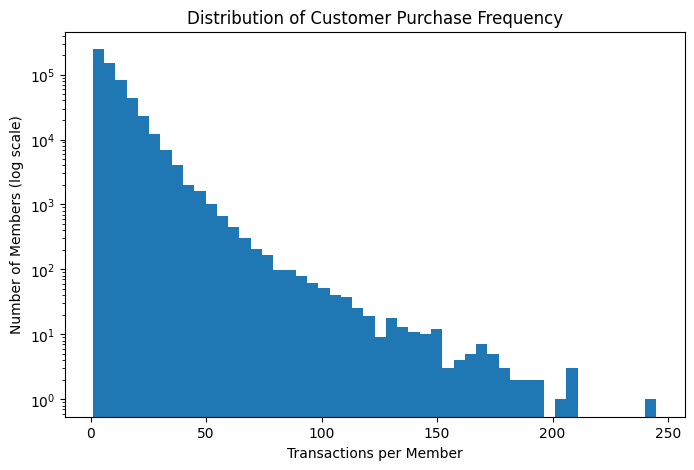

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df_tx["transactions"], bins=50, log=True)

plt.xlabel("Transactions per Member")
plt.ylabel("Number of Members (log scale)")
plt.title("Distribution of Customer Purchase Frequency")

plt.show()

Purchase frequency exhibits a strongly right\-skewed distribution\. While the median customer completes seven transactions, a small group of highly active customers performs substantially more purchases, with some exceeding 200 transactions\. This heterogeneity suggests that a minority of customers contributes disproportionately to transaction activity\.

### Basket size \(products per transaction\)

In [12]:
basket_size = con.execute("""
WITH baskets AS (
    SELECT
        transaction_id,
        COUNT(*) AS products
    FROM '/work/data/parquets/fact_sales_v2.parquet'
    GROUP BY transaction_id
)

SELECT
    MIN(products) AS min_products,
    AVG(products) AS avg_products,
    MAX(products) AS max_products
FROM baskets
""").arrow()

pl.from_arrow(basket_size)

min_products,avg_products,max_products
i64,f64,i64
1,2.454527,265


Transactions typically contain a small number of products, with an average basket size of approximately 2\.45 items\. This suggests that most purchases represent focused shopping missions rather than large multi\-category baskets\.

In [15]:
basket_dist = con.execute("""
WITH baskets AS (
    SELECT
        transaction_id,
        COUNT(*) AS products
    FROM '/work/data/parquets/fact_sales_v2.parquet'
    GROUP BY transaction_id
)

SELECT
    products,
    COUNT(*) AS num_transactions
FROM baskets
GROUP BY products
ORDER BY products
LIMIT 50
""").arrow()

pl.from_arrow(basket_dist)

products,num_transactions
i64,i64
1,2218300
2,1294355
3,721689
4,418052
5,231728
…,…
46,10
47,11
48,6


### Revenue per transaction

In [18]:
transaction_value = con.execute("""
WITH transactions AS (
    SELECT
        transaction_id,
        SUM(revenue) AS basket_value
    FROM '/work/data/parquets/fact_sales_v2.parquet'
    GROUP BY transaction_id
)

SELECT
    MIN(basket_value) AS min_value,
    AVG(basket_value) AS avg_value,
    MAX(basket_value) AS max_value
FROM transactions
""").arrow()

pl.from_arrow(transaction_value)

min_value,avg_value,max_value
f64,f64,f64
-14844.0,286.724705,49035.71


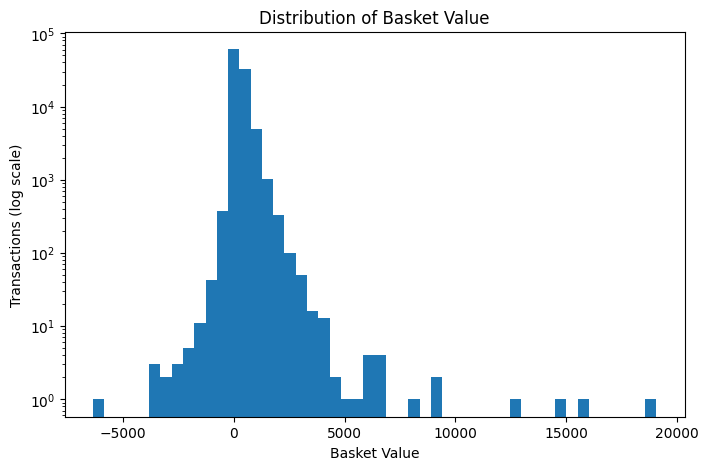

In [21]:
basket_values = con.execute("""
WITH transactions AS (
    SELECT
        transaction_id,
        SUM(revenue) AS basket_value
    FROM '/work/data/parquets/fact_sales_v2.parquet'
    GROUP BY transaction_id
)

SELECT *
FROM transactions
USING SAMPLE 100000
""").arrow()

df_basket = pl.from_arrow(basket_values)

plt.figure(figsize=(8,5))
plt.hist(df_basket["basket_value"], bins=50, log=True)

plt.xlabel("Basket Value")
plt.ylabel("Transactions (log scale)")
plt.title("Distribution of Basket Value")

plt.show()

### Channel behavior

In [24]:
channel_mix = con.execute("""
SELECT
    channel,
    COUNT(*) AS rows,
    SUM(revenue) AS revenue
FROM '/work/data/parquets/fact_sales_v2.parquet'
GROUP BY channel
ORDER BY revenue DESC
""").arrow()

pl.from_arrow(channel_mix)

channel,rows,revenue
str,i64,f64
"""Store""",9412185,1.0202e9
"""Web""",3541983,4.9304e8


Physical stores remain the dominant purchase channel, accounting for the majority of transactions and revenue\. However, online sales represent a substantial share of customer activity, indicating the presence of meaningful multichannel behavior\.

### Revenue per customer

In [25]:
customer_value = con.execute("""
SELECT
    matas_id,
    SUM(revenue) AS total_spend,
    COUNT(DISTINCT transaction_id) AS transactions
FROM '/work/data/parquets/fact_sales_v2.parquet'
GROUP BY matas_id
""").arrow()

df_value = pl.from_arrow(customer_value)

df_value.describe()

statistic,matas_id,total_spend,transactions
str,str,f64,f64
"""count""","""573421""",573421.0,573421.0
"""null_count""","""0""",0.0,0.0
"""mean""",null,2638.962236,9.203819
"""std""",null,3231.422063,9.221225
"""min""","""+++EOcOLigaZxJ2L7AOHGqXdilj0HHXi2mA+6mQdJYw=""",-27402.59,1.0
"""25%""",null,735.64,3.0
"""50%""",null,1676.5,7.0
"""75%""",null,3373.48,12.0
"""max""","""zzzrFY47hn9rhZZ3g0pt3pHKd9dD9FovvH9y2cDD2ww=""",378761.99,245.0


Customer spending is highly concentrated, with a small number of customers generating exceptionally high total revenue\.

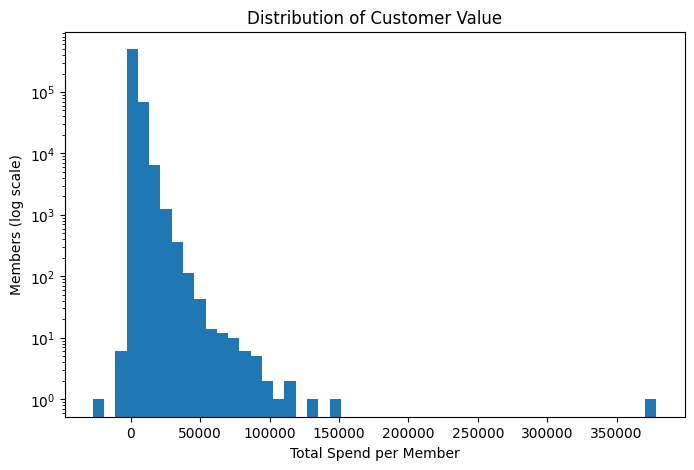

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df_value["total_spend"], bins=50, log=True)

plt.xlabel("Total Spend per Member")
plt.ylabel("Members (log scale)")
plt.title("Distribution of Customer Value")

plt.show()

## Campaign Sales

### Campaign purchases per customer

In [29]:
campaign_purchases = con.execute("""
SELECT
    matas_id,
    COUNT(*) AS campaign_rows
FROM '/work/data/parquets/fact_campaign_sales_v2.parquet'
GROUP BY matas_id
""").arrow()

df_campaign = pl.from_arrow(campaign_purchases)

df_campaign.describe()

statistic,matas_id,campaign_rows
str,str,f64
"""count""","""438076""",438076.0
"""null_count""","""0""",0.0
"""mean""",null,7.54018
"""std""",null,11.882291
"""min""","""+++EOcOLigaZxJ2L7AOHGqXdilj0HHXi2mA+6mQdJYw=""",1.0
"""25%""",null,2.0
"""50%""",null,4.0
"""75%""",null,8.0
"""max""","""zzzrFY47hn9rhZZ3g0pt3pHKd9dD9FovvH9y2cDD2ww=""",608.0


Campaign purchases are unevenly distributed across customers\. While most members participate in campaigns only occasionally, a subset of highly active campaign shoppers exhibits extremely high levels of campaign\-driven purchasing\.

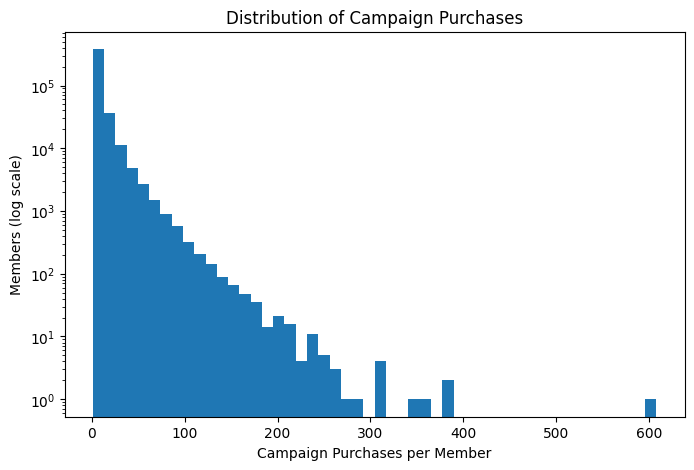

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df_campaign["campaign_rows"], bins=50, log=True)

plt.xlabel("Campaign Purchases per Member")
plt.ylabel("Members (log scale)")
plt.title("Distribution of Campaign Purchases")

plt.show()

### Revenue from campaigns

In [33]:
campaign_revenue = con.execute("""
SELECT
    SUM(revenue) AS total_campaign_revenue,
    AVG(revenue) AS avg_row_revenue,
    COUNT(*) AS rows
FROM '/work/data/parquets/fact_campaign_sales_v2.parquet'
""").arrow()

pl.from_arrow(campaign_revenue)

total_campaign_revenue,avg_row_revenue,rows
f64,f64,i64
5.3852e8,163.031722,3303172


Campaign sales generate substantial revenue, indicating that promotional campaigns play a central role in driving purchase activity\.

### Campaign participation rate

In [36]:
campaign_members = con.execute("""
SELECT
    COUNT(DISTINCT matas_id) AS members_in_campaigns
FROM '/work/data/parquets/fact_campaign_sales_v2.parquet'
""").arrow()

pl.from_arrow(campaign_members)

members_in_campaigns
i64
438076


Approximately three quarters of customers engage in at least one promotional campaign purchase, highlighting the widespread reach of marketing campaigns within the customer base\.

### Top campaigns

In [37]:
top_campaigns = con.execute("""
SELECT
    campaign_id,
    COUNT(*) AS rows,
    SUM(revenue) AS revenue
FROM '/work/data/parquets/fact_campaign_sales_v2.parquet'
GROUP BY campaign_id
ORDER BY revenue DESC
LIMIT 20
""").arrow()

pl.from_arrow(top_campaigns)

campaign_id,rows,revenue
str,i64,f64
"""854711""",245518,3.7258e7
"""85184""",168421,2.2605e7
"""85263""",160462,2.0112e7
"""85322""",134048,1.7587e7
"""85094""",90937,1.2726e7
…,…,…
"""1009039""",49613,6.8988e6
"""85162""",35661,6.8284e6
"""85432""",18765,6.7667e6


Campaign activity is concentrated among a subset of highly successful promotions, suggesting substantial heterogeneity in campaign effectiveness\.

## Points

### Points earned / burned per member

In [38]:
points_per_member = con.execute("""
SELECT
    matas_id,
    SUM(points) AS total_points,
    COUNT(*) AS events
FROM '/work/data/parquets/fact_points_v2.parquet'
GROUP BY matas_id
""").arrow()

df_points = pl.from_arrow(points_per_member)

df_points.describe()

statistic,matas_id,total_points,events
str,str,f64,f64
"""count""","""573124""",573124.0,573124.0
"""null_count""","""0""",0.0,0.0
"""mean""",null,33.132526,14.319622
"""std""",null,267.822886,14.192941
"""min""","""+++EOcOLigaZxJ2L7AOHGqXdilj0HHXi2mA+6mQdJYw=""",-15120.0,1.0
"""25%""",null,-44.0,5.0
"""50%""",null,39.0,11.0
"""75%""",null,110.0,19.0
"""max""","""zzzrFY47hn9rhZZ3g0pt3pHKd9dD9FovvH9y2cDD2ww=""",48897.0,318.0


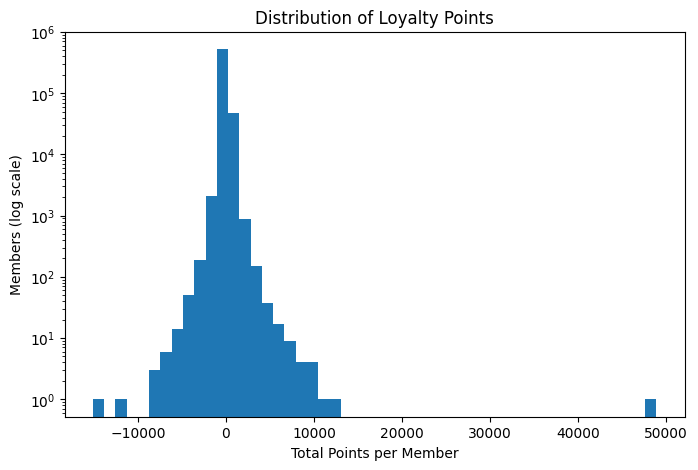

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df_points["total_points"], bins=50, log=True)

plt.xlabel("Total Points per Member")
plt.ylabel("Members (log scale)")
plt.title("Distribution of Loyalty Points")

plt.show()

Loyalty point balances vary widely across customers, reflecting both point accumulation and redemption behavior within the loyalty program\.

### Point event types

In [40]:
point_types = con.execute("""
SELECT
    point_type,
    COUNT(*) AS rows,
    SUM(points) AS total_points
FROM '/work/data/parquets/fact_points_v2.parquet'
GROUP BY point_type
ORDER BY rows DESC
""").arrow()

pl.from_arrow(point_types)

point_type,rows,total_points
str,i64,"decimal[38,0]"
"""Earned""",7404712,224185197
"""Redeemed""",802207,-205196151


Point accumulation events substantially outnumber redemption events, suggesting that customers accumulate points over time before redeeming rewards\.

### Points activity per customer

In [10]:
points_events = con.execute("""
SELECT
    matas_id,
    COUNT(*) AS point_events
FROM '/work/data/parquets/fact_points_v2.parquet'
GROUP BY matas_id
""").arrow()

df_events = pl.from_arrow(points_events)

df_events.describe()

statistic,matas_id,point_events
str,str,f64
"""count""","""573124""",573124.0
"""null_count""","""0""",0.0
"""mean""",null,14.319622
"""std""",null,14.192941
"""min""","""+++EOcOLigaZxJ2L7AOHGqXdilj0HHXi2mA+6mQdJYw=""",1.0
"""25%""",null,5.0
"""50%""",null,11.0
"""75%""",null,19.0
"""max""","""zzzrFY47hn9rhZZ3g0pt3pHKd9dD9FovvH9y2cDD2ww=""",318.0


## Web sessions

### Events per session

In [34]:
session_stats = con.execute("""
WITH sessions AS (
    SELECT
        session_id,
        COUNT(*) AS events
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE session_id IS NOT NULL
    GROUP BY session_id
)
SELECT
    MIN(events) AS min_events,
    AVG(events) AS avg_events,
    MAX(events) AS max_events
FROM sessions
""").arrow()

pl.from_arrow(session_stats)

In [35]:
session_distribution = con.execute("""
WITH sessions AS (
    SELECT
        session_id,
        COUNT(*) AS events
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE session_id IS NOT NULL
    GROUP BY session_id
)
SELECT
    events,
    COUNT(*) AS num_sessions
FROM sessions
GROUP BY events
ORDER BY events
LIMIT 50
""").arrow()

pl.from_arrow(session_distribution)

### Session duration

In [36]:
session_duration = con.execute("""
WITH web AS (
    SELECT
        session_id,
        CAST(event_timestamp AS TIMESTAMP) AS ts
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE session_id IS NOT NULL
)
SELECT
    session_id,
    MIN(ts) AS session_start,
    MAX(ts) AS session_end,
    date_diff('second', MIN(ts), MAX(ts)) AS session_duration_seconds
FROM web
GROUP BY session_id
USING SAMPLE 100000
""").arrow()

pl.from_arrow(session_duration)

In [37]:
session_duration = con.execute("""
WITH web AS (
    SELECT
        session_id,
        CAST(event_timestamp AS TIMESTAMP) AS ts
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE session_id IS NOT NULL
),
sessions AS (
    SELECT
        session_id,
        date_diff('second', MIN(ts), MAX(ts)) / 60.0 AS duration_minutes
    FROM web
    GROUP BY session_id
)
SELECT *
FROM sessions
USING SAMPLE 100000
""").arrow()

df = pl.from_arrow(session_duration)
filtered = df.filter(pl.col("duration_minutes") <= 60)

plt.figure(figsize=(8,5))
plt.hist(filtered["duration_minutes"], bins=50)

plt.xlabel("Session duration (minutes)")
plt.ylabel("Number of sessions")
plt.title("Session Duration Distribution (0–60 min)")

plt.show()

This histogram actually looks very healthy and exactly what we expect from real web session data\. 

The session duration histogram shows a highly right\-skewed distribution with a large spike at 0 minutes and a rapidly decreasing frequency as duration increases, which is typical for e\-commerce clickstream data\. The spike at zero reflects a high number of single\-event sessions \(e\.g\., users who viewed only one page\), commonly referred to as bounce sessions\. After this initial spike, the number of sessions declines sharply, with most sessions lasting only a few minutes and progressively fewer sessions extending toward longer durations\. The long but thin tail up to around 60 minutes likely represents more engaged browsing behavior or cases where users leave a tab open\. Overall, this pattern is consistent with realistic web browsing behavior and suggests that session tracking and timestamp calculations are functioning correctly\.

In [38]:
bounce_rate = con.execute("""
WITH session_events AS (
    SELECT
        session_id,
        COUNT(*) AS events
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE session_id IS NOT NULL
    GROUP BY session_id
)

SELECT
    COUNT(*) AS total_sessions,
    COUNT(*) FILTER (WHERE events = 1) AS bounce_sessions,
    COUNT(*) FILTER (WHERE events = 1) * 1.0 / COUNT(*) AS bounce_rate
FROM session_events
""").arrow()

pl.from_arrow(bounce_rate)

Definition: A bounce session contains only one event

The computed bounce rate of **44.9%** indicates that slightly less than half of all sessions consist of a single recorded event, meaning users left the site without performing additional tracked actions beyond their initial interaction (e.g., a single page view). This level of bounce rate is consistent with typical **retail and e-commerce browsing behavior**, where many visitors quickly view a product or landing page before exiting. Combined with the session duration distribution, this suggests that the session tracking logic is functioning as expected and that user behavior follows a realistic pattern, characterized by a large share of short visits and a smaller proportion of longer, more engaged sessions.

NB: The bounce rate calculation is an industry standard calculation, but it also includes sessions with event = purchase\.  

In [39]:
# Filter non-bounce sessions with duration between 0 and 60 minutes (exclusive of 0, less than 50)
non_bounce = df.filter((pl.col("duration_minutes") > 0) & (pl.col("duration_minutes") < 50))

plt.figure(figsize=(8,5))
plt.hist(non_bounce["duration_minutes"], bins=50)

plt.xlabel("Session duration (minutes)")
plt.ylabel("Number of sessions")
plt.title("Session Duration (0–60 min, excluding bounce sessions)")

plt.show()

### Conversion funnel

Each row represents one session, and the columns indicate whether a certain event occurred during that session\.

In [40]:
session_funnel = con.execute("""
SELECT
    session_id,
    MAX(CASE WHEN event_name='page_view' THEN 1 ELSE 0 END) AS has_page_view,
    MAX(CASE WHEN event_name='add_to_cart' THEN 1 ELSE 0 END) AS has_add_to_cart,
    MAX(CASE WHEN event_name='purchase' THEN 1 ELSE 0 END) AS has_purchase
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
WHERE session_id IS NOT NULL
GROUP BY session_id
LIMIT 100000
""").arrow()

pl.from_arrow(session_funnel)

1\-0\-0 = browsing session

1\-1\-0 = cart abandonment

1\-1\-1 = completed purchase

1\-0\-1 = purchase without cart \- \(This means the user purchased without a tracked add\_to\_cart event\.\) 

0\-0\-1 = purchase only \(The purchase happened in another session \- normal in real clickstream data\) 

In [41]:
funnel_stats = con.execute("""
WITH session_funnel AS (
    SELECT
        session_id,
        MAX(CASE WHEN event_name='page_view' THEN 1 ELSE 0 END) AS has_page_view,
        MAX(CASE WHEN event_name='add_to_cart' THEN 1 ELSE 0 END) AS has_add_to_cart,
        MAX(CASE WHEN event_name='purchase' THEN 1 ELSE 0 END) AS has_purchase
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE session_id IS NOT NULL
    GROUP BY session_id
)
SELECT
    COUNT(*) AS total_sessions,
    SUM(has_page_view) AS sessions_with_page_view,
    SUM(has_add_to_cart) AS sessions_with_cart,
    SUM(has_purchase) AS sessions_with_purchase
FROM session_funnel
""").arrow()

pl.from_arrow(funnel_stats)

### Funnel conversion rates

In typical e\-commerce operations:
add\_to\_cart	5–10%
purchase	2–4%

In [42]:
funnel_rates = con.execute("""
WITH session_funnel AS (
    SELECT
        session_id,
        MAX(CASE WHEN event_name='page_view' THEN 1 ELSE 0 END) AS has_page_view,
        MAX(CASE WHEN event_name='add_to_cart' THEN 1 ELSE 0 END) AS has_add_to_cart,
        MAX(CASE WHEN event_name='purchase' THEN 1 ELSE 0 END) AS has_purchase
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE session_id IS NOT NULL
    GROUP BY session_id
)
SELECT
    COUNT(*) AS sessions,
    SUM(has_page_view) * 1.0 / COUNT(*) AS page_view_rate,
    SUM(has_add_to_cart) * 1.0 / COUNT(*) AS cart_rate,
    SUM(has_purchase) * 1.0 / COUNT(*) AS purchase_rate
FROM session_funnel
""").arrow()

pl.from_arrow(funnel_rates)

The session\-level funnel analysis shows that 65\.5% of sessions contain a page view, 11\.8% include an add\-to\-cart event, and 49\.1% include a purchase event\. The add\-to\-cart rate is consistent with typical e\-commerce behavior, indicating that around one in ten sessions involves product consideration\. However, the purchase rate is unusually high relative to the cart rate, suggesting that many sessions contain a purchase event without preceding browsing actions\. This likely reflects the way transactions are tracked in the dataset, where checkout sessions may be recorded independently of earlier browsing sessions\. Consequently, the funnel should be interpreted as describing different types of sessions rather than a strict sequential conversion process\.

In [43]:
conditional_funnel = con.execute("""
WITH session_funnel AS (
    SELECT
        session_id,
        MAX(CASE WHEN event_name='page_view' THEN 1 ELSE 0 END) AS page_view,
        MAX(CASE WHEN event_name='add_to_cart' THEN 1 ELSE 0 END) AS cart,
        MAX(CASE WHEN event_name='purchase' THEN 1 ELSE 0 END) AS purchase
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE session_id IS NOT NULL
    GROUP BY session_id
)
SELECT
    SUM(page_view) AS page_views,
    SUM(cart) AS carts,
    SUM(purchase) AS purchases,
    SUM(cart) * 1.0 / SUM(page_view) AS cart_from_view_rate,
    SUM(purchase) * 1.0 / SUM(cart) AS purchase_from_cart_rate
FROM session_funnel
""").arrow()

pl.from_arrow(conditional_funnel)

The session\-level funnel analysis indicates that 4\.73 million sessions contain page views, 851 thousand include an add\-to\-cart event, and 3\.55 million contain a purchase event\. Approximately 18% of sessions with page views include a cart interaction, which is consistent with typical e\-commerce browsing behavior, where only a minority of sessions involve product consideration\. However, the calculated purchase\-from\-cart rate exceeds 400%, indicating that many sessions include a purchase event without a preceding add\-to\-cart action\. This suggests that transactions are often recorded in separate sessions or without the full browsing sequence, meaning the events do not represent a strictly sequential conversion funnel\. Instead, the results should be interpreted as describing different types of sessions rather than a complete browsing\-to\-purchase journey\.

### Matching web sessions to members

A validation check was performed to determine whether the `matas_id` used in the web session dataset corresponds to the member identifier in the customer dimension. The results show a **100% overlap**, meaning every web session identifier matches a member in the `dim_member` table. In total, **567,329 unique members appear in the web sessions dataset**, compared to **573,421 total registered members**, implying that approximately **98.9% of members have at least one recorded web session**. This confirms that the same hashed identifier is used across datasets and allows web behaviour to be directly linked to customer attributes. The very high share of members with web sessions suggests that **the dataset likely focuses on members who interacted with the website during the observation period, rather than representing a random sample of all customers**. This alignment enables integrated analysis of online behaviour, purchases, and customer characteristics within the thesis.

In [44]:
sessions_per_member = con.execute(f"""
WITH sessions_per_member AS (
    SELECT
        matas_id,
        COUNT(*) AS session_count
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    GROUP BY matas_id
)

SELECT
    COUNT(*) AS members_with_sessions,
    AVG(session_count) AS avg_sessions_per_member,
    MEDIAN(session_count) AS median_sessions_per_member,
    MIN(session_count) AS min_sessions,
    MAX(session_count) AS max_sessions
FROM sessions_per_member
""").arrow()


pl.from_arrow(sessions_per_member)

In [45]:
distribution = con.execute(f"""
WITH sessions_per_member AS (
    SELECT
        matas_id,
        COUNT(*) AS session_count
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    GROUP BY matas_id
)

SELECT
    CASE
        WHEN session_count = 1 THEN '1 session'
        WHEN session_count BETWEEN 2 AND 5 THEN '2–5 sessions'
        WHEN session_count BETWEEN 6 AND 10 THEN '6–10 sessions'
        WHEN session_count BETWEEN 11 AND 50 THEN '11–50 sessions'
        WHEN session_count BETWEEN 51 AND 100 THEN '51–100 sessions'
        ELSE '100+ sessions'
    END AS session_group,
    COUNT(*) AS members
FROM sessions_per_member
GROUP BY session_group
ORDER BY members DESC
""").arrow()

pl.from_arrow(distribution)

An analysis of web engagement shows that **567,329 members generated web sessions during the observation period**, corresponding to approximately **98.9% of all registered members**. On average, members generated **68.2 web sessions**, while the **median is significantly lower at 17 sessions**, indicating a **strongly right-skewed distribution** in which a smaller group of highly active users accounts for a disproportionate share of total sessions. The minimum number of sessions per member is **1**, while the most active member recorded **34,701 sessions**, further illustrating the presence of extreme high-frequency users.

The distribution of sessions across members reinforces this skewness. The largest group consists of members with **11–50 sessions (189,024 members)**, followed by **2–5 sessions (102,089)** and **6–10 sessions (83,674)**. Notably, a substantial segment of **93,819 members generated more than 100 sessions**, highlighting the presence of a highly engaged user base. In contrast, only **33,553 members recorded a single session**, suggesting that most members interact with the website repeatedly rather than visiting only once.

Overall, these results indicate that **web engagement among members is widespread and recurring**, with the majority of members returning multiple times. At the same time, the large gap between the mean and median session counts suggests that **a relatively small group of highly active members drives a large portion of total web activity**. This pattern is typical for digital platforms and suggests that analysing differences between low-, medium-, and high-engagement members may provide valuable insights for understanding customer behaviour in the context of this thesis.

In [46]:
power_users = con.execute(f"""
WITH sessions_per_member AS (
    SELECT
        matas_id,
        COUNT(*) AS session_count
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    GROUP BY matas_id
),

ranked_members AS (
    SELECT
        matas_id,
        session_count,
        NTILE(10) OVER (ORDER BY session_count DESC) AS activity_decile
    FROM sessions_per_member
),

total_sessions AS (
    SELECT SUM(session_count) AS total_sessions
    FROM sessions_per_member
)

SELECT
    SUM(CASE WHEN activity_decile = 1 THEN session_count ELSE 0 END) AS top_10pct_sessions,
    SUM(session_count) AS total_sessions,
    SUM(CASE WHEN activity_decile = 1 THEN session_count ELSE 0 END) * 1.0
        / SUM(session_count) * 100 AS pct_sessions_from_top10
FROM ranked_members
""").arrow()

pl.from_arrow(power_users)

An additional analysis examined whether web activity is concentrated among a small group of highly active members. Members were ranked based on their total number of web sessions and divided into activity deciles. The results show that the top 10% most active members generate a disproportionately large share of total web sessions. This indicates a strong “power-user” effect, where a relatively small segment of highly engaged customers accounts for a substantial portion of online activity. Such skewed engagement patterns are commonly observed in digital platforms and highlight the importance of identifying and understanding highly active customers, as they may represent particularly valuable or loyal segments within the customer base.

Additional analysis confirms a strong **“power-user” effect**. The **top 10% most active members generate approximately 61% of all web sessions (23.6 million out of 38.7 million sessions)**. This indicates that web activity is highly concentrated among a relatively small segment of highly engaged users. Such patterns are commonly observed in digital platforms and suggest that a subset of customers plays a disproportionately important role in overall online engagement. Identifying and understanding these highly active members may therefore be particularly valuable for analysing customer behaviour and engagement within the Matas ecosystem.

### User\-level sessions

The initial analysis constructed a conversion funnel at the **session level**, identifying whether each session contained a `page_view`, `add_to_cart`, or `purchase` event. However, the results showed that the **purchase rate exceeded the add-to-cart rate**, which indicates that sessions do not represent a complete browsing-to-purchase journey. In e-commerce, users often browse in one session and complete the purchase in another (e.g., returning directly to checkout or purchasing from a saved cart). As a result, **session-based funnels cannot reliably capture sequential customer behavior**. To address this, the analysis moves to a **user-level funnel**, aggregating events by `matas_id`. This approach captures the full journey across multiple sessions and is feasible because the web session data contains the `matas_id`, allowing it to be directly matched to the member dataset. **User journey funnels therefore provide a more realistic representation of customer behavior across the platform.**

In [47]:
user_funnel = con.execute("""
WITH user_events AS (
    SELECT
        matas_id,
        MAX(CASE WHEN event_name = 'page_view' THEN 1 ELSE 0 END) AS viewed,
        MAX(CASE WHEN event_name = 'add_to_cart' THEN 1 ELSE 0 END) AS added_to_cart,
        MAX(CASE WHEN event_name = 'purchase' THEN 1 ELSE 0 END) AS purchased
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE matas_id IS NOT NULL
    GROUP BY matas_id
)

SELECT
    COUNT(*) AS total_users,
    SUM(viewed) AS users_viewed,
    SUM(added_to_cart) AS users_added_to_cart,
    SUM(purchased) AS users_purchased,
    SUM(added_to_cart) * 1.0 / SUM(viewed) AS cart_from_view_rate,
    SUM(purchased) * 1.0 / SUM(added_to_cart) AS purchase_from_cart_rate
FROM user_events
""").arrow()

pl.from_arrow(user_funnel)

In [48]:
journey_types = con.execute("""
WITH user_events AS (
    SELECT
        matas_id,
        MAX(CASE WHEN event_name = 'page_view' THEN 1 ELSE 0 END) AS viewed,
        MAX(CASE WHEN event_name = 'add_to_cart' THEN 1 ELSE 0 END) AS cart,
        MAX(CASE WHEN event_name = 'purchase' THEN 1 ELSE 0 END) AS purchase
    FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
    WHERE matas_id IS NOT NULL
    GROUP BY matas_id
)

SELECT
    viewed,
    cart,
    purchase,
    COUNT(*) AS users
FROM user_events
GROUP BY viewed, cart, purchase
ORDER BY users DESC
""").arrow()

pl.from_arrow(journey_types)

Aggregating events at the user level reveals that many customers have recorded purchase events without corresponding browsing or add-to-cart events. In particular, **215,239 users appear with purchase events only**, suggesting that transactions are frequently recorded in sessions separate from browsing activity. This may occur when users return directly to checkout, purchase from saved carts, or complete transactions through different channels or tracking flows.

A substantial share of users (**209,235**) follow the expected browsing path of viewing products, adding them to the cart, and completing a purchase. However, many users (**130,536**) move directly from product viewing to purchase without a recorded add-to-cart event, which may reflect fast checkout flows or incomplete cart tracking.

Overall, these results indicate that **web sessions do not consistently capture the full browsing-to-purchase sequence**, and therefore should not be interpreted as a strict sequential funnel. Instead, the web data is better understood as **a record of member activity across multiple sessions**, where different stages of the purchasing journey may occur in separate visits.

Next we run Unique Users per Event \(Diagnostic Check\) \- This helps verify whether purchase events dominate the dataset, which would explain why the funnel looked inconsistent\.

In [49]:
unique_users_per_event = con.execute("""
SELECT
    event_name,
    COUNT(DISTINCT matas_id) AS unique_users
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
WHERE matas_id IS NOT NULL
GROUP BY event_name
ORDER BY unique_users DESC
""").arrow()

pl.from_arrow(unique_users_per_event)

Examining the number of unique users associated with each event type reveals an important structural characteristic of the web session dataset. Purchase events appear for **563,723 users**, whereas **343,350 users generate page view events** and **218,885 users generate add-to-cart events**.

This imbalance indicates that **purchase events are recorded for a substantially larger set of users than browsing interactions**. In other words, many users appear in the dataset with purchase events but without corresponding browsing events such as page views or cart interactions. This pattern suggests that **transactions are frequently recorded independently of browsing activity**, which may occur when users return directly to checkout, complete purchases in separate sessions, or interact through different channels where browsing behavior is not captured in the same event stream.

Additionally, the number of users associated with purchase events is very close to the total number of users in the dataset, indicating that **the web session data is strongly biased toward purchasing members rather than general website visitors**. This is consistent with the structure of the dataset, which focuses on **Club Matas members and their recorded interactions**. As a result, the web session dataset should not be interpreted as a complete sequential browsing funnel but rather as **a record of member activity across multiple sessions and tracking flows**.

### Events per user \(engagement level\)

In [50]:
events_per_user = con.execute("""
SELECT
    matas_id,
    COUNT(*) AS events
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
WHERE matas_id IS NOT NULL
GROUP BY matas_id
""").arrow()

df_events = pl.from_arrow(events_per_user)

df_events.describe()

In [51]:
plt.figure(figsize=(8,5))
plt.hist(df_events["events"], bins=50, log=True)
plt.xlabel("Number of Web Events per User")
plt.ylabel("Number of Users (log scale)")
plt.title("Distribution of Web Engagement (log scale)")
plt.show()

To measure how actively members interact with the digital platform, we compute the total number of web events generated by each user. The distribution is highly skewed, with a small number of users generating very large numbers of events.

Key statistics show that the **average user generates approximately 68 events**, while the **median user generates only 17 events**, indicating that a relatively small group of highly active users significantly increases the overall mean. The interquartile range further illustrates this skew: **25% of users generate 6 or fewer events**, while **75% generate 60 or fewer events**.

The maximum value of **34,701 events for a single user** highlights the presence of extremely active members, which likely represent heavy users who frequently browse products, compare items, or interact repeatedly with the platform.

**Key insights**

- **Web engagement is highly skewed**, with a small group of very active users driving a large share of total interactions.
- **The median (17 events) is much lower than the mean (68 events)**, confirming the presence of heavy-tail behavior typical for digital engagement data.
- **Most members exhibit relatively moderate engagement**, while a small minority generate extremely high interaction volumes.
- This pattern suggests that **a limited group of highly engaged members may account for a disproportionate share of digital activity**, making engagement intensity an important behavioral dimension for later analysis.

### Sessions per user

In [52]:
sessions_per_user = con.execute("""
SELECT
    matas_id,
    COUNT(DISTINCT session_id) AS sessions
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
WHERE matas_id IS NOT NULL
GROUP BY matas_id
""").arrow()

df_sessions = pl.from_arrow(sessions_per_user)

df_sessions.describe()

In [53]:
df_events.sort("events", descending=True).head(20)

In addition to event counts, we examine the number of sessions generated by each user to understand how frequently members return to the platform. The results again reveal a highly skewed distribution of activity.

On average, users generate **approximately 17 sessions**, while the **median user has 10 sessions**, indicating that many members interact with the platform multiple times over the observation period. The distribution shows that **25% of users have four or fewer sessions**, whereas **75% have twenty or fewer sessions**.

The maximum value of **1,610 sessions for a single user** demonstrates the presence of extremely frequent visitors who repeatedly return to the platform.

**Key insights**

- **Most members interact with the platform repeatedly**, with a median of 10 sessions per user.
- **Engagement intensity varies widely across the member base**, ranging from occasional visits to extremely frequent usage.
- **The strong right-skew indicates the presence of a small group of highly active users who generate a disproportionate share of sessions.**
- These patterns suggest that **customer engagement with the digital platform is heterogeneous**, making session frequency a potentially valuable indicator of behavioral engagement in later analyses.

In [54]:
events_per_session = con.execute("""
SELECT
    session_id,
    COUNT(*) as events
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
GROUP BY session_id
ORDER BY events DESC
LIMIT 20
""").arrow()

pl.from_arrow(events_per_session)

To further assess whether extreme engagement values are driven by unusually large sessions, the number of events per session was examined. Most sessions contain relatively modest numbers of interactions, but a small number of sessions contain **hundreds of recorded events**, with the largest sessions exceeding **900 events**.

Additionally, a large number of events are associated with a **NULL session identifier**, indicating that these interactions are not linked to a specific tracked session.

**Key insights**

- **Most sessions appear to contain a reasonable number of interactions**, suggesting normal browsing behavior.
- **Some sessions contain very large numbers of events**, which may occur when users browse many products or repeatedly interact with the platform during a single visit.
- **A substantial number of events are associated with a NULL session_id**, indicating that certain interactions are recorded without an identifiable session context.
- This suggests that **the web event stream may include interactions that are not fully sessionized**, reinforcing earlier findings that the dataset should be interpreted as a **member activity log rather than a strict browsing-session dataset.**

In [55]:
check = con.execute("""
SELECT event_name, COUNT(*)
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
WHERE session_id IS NULL
GROUP BY event_name
""").arrow()

pl.from_arrow(check)

To further investigate the unusually large number of events associated with a `NULL` session identifier, the distribution of event types within these records was examined. The results show that **230,191 purchase events**, **48,260 add-to-cart events**, and only **2,763 page view events** occur without an associated session identifier.

This pattern suggests that **many transactional interactions are recorded independently of browsing sessions**. In particular, the large number of purchase events without a session identifier indicates that transactions may be logged through systems or tracking flows that do not attach a session context.

**Key insights**

- **A substantial number of purchase events are recorded without a session identifier**, indicating that transactions are often logged outside standard session tracking.
- **Add-to-cart events also appear frequently without session identifiers**, suggesting that some interaction flows bypass or lose session attribution.
- **Page view events rarely occur without session identifiers**, reinforcing the interpretation that browsing activity is more consistently tied to tracked sessions.
- These results further support the conclusion that **the web event dataset should be interpreted as a record of member activity rather than a strictly session-based browsing dataset.**

NB: When doing session\-based analysis, we might want to filter out those events \(WHERE session\_id IS NOT NULL\), because otherwise the NULL cluster acts like one giant artificial session\.

### Event Mix per User

In [56]:
event_mix = con.execute("""
SELECT
    matas_id,
    SUM(CASE WHEN event_name='page_view' THEN 1 ELSE 0 END) AS page_views,
    SUM(CASE WHEN event_name='add_to_cart' THEN 1 ELSE 0 END) AS cart_events,
    SUM(CASE WHEN event_name='purchase' THEN 1 ELSE 0 END) AS purchase_events
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
WHERE matas_id IS NOT NULL
GROUP BY matas_id
LIMIT 100000
""").arrow()

pl.from_arrow(event_mix)

# Layer 4 \- Temporal EDA

### Time Coverage & Consistency

Verify that all datasets cover comparable periods and that time-series behavior is sensible before running behavioral analyses. This is important because our hypotheses rely on future behavior (CLV, frequency) and campaign exposure over time, so temporal alignment matters.

In [22]:
def duck_range(con, source, date_col, name):
    res = con.execute(f"""
        SELECT
            MIN({date_col}) AS min_date,
            MAX({date_col}) AS max_date
        FROM '{source}'
    """).arrow()

    return pl.from_arrow(res).with_columns(
        pl.lit(name).alias("dataset")
    )

ranges = pl.concat([
    duck_range(con, "/work/data/parquets/fact_sales_v2.parquet", "sales_date", "sales"),
    duck_range(con, "/work/data/parquets/fact_campaign_sales_v2.parquet", "sales_date", "campaign_sales"),
    duck_range(con, "/work/data/parquets/fact_points_v2.parquet", "point_date", "points"),
    duck_range(con, "/work/data/parquets/fact_web_sessions_v2.parquet", "event_date", "web_sessions"),
])

ranges

min_date,max_date,dataset
date,date,str
2024-12-19,2025-12-18,"""sales"""
2024-12-20,2025-12-17,"""campaign_sales"""
2024-12-19,2025-12-18,"""points"""
2024-12-19,2025-12-19,"""web_sessions"""


### Temporal Density \(Transactions Over Time\)

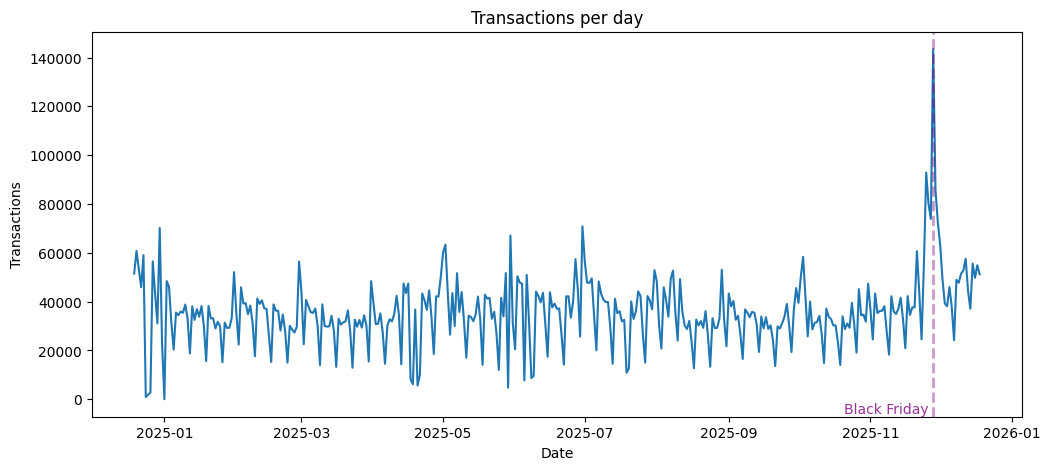

In [43]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(sales_daily["sales_date"], sales_daily["transactions"])

add_black_friday(ax)

ax.set_title("Transactions per day")
ax.set_xlabel("Date")
ax.set_ylabel("Transactions")

plt.show()

### Revenue Over Time

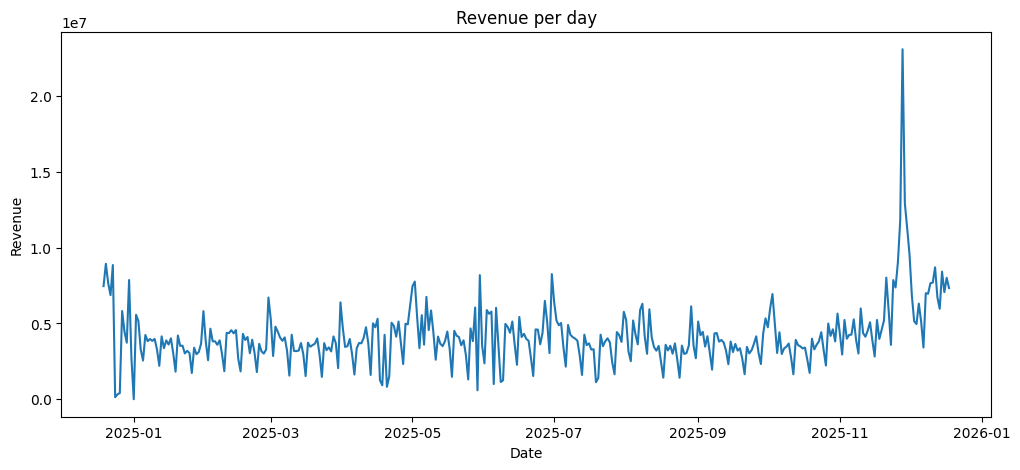

In [27]:
revenue_daily = (
    fact_sales
    .group_by("sales_date")
    .agg(pl.sum("revenue").alias("revenue"))
    .sort("sales_date")
    .collect()
)

plt.figure(figsize=(12,5))
plt.plot(revenue_daily["sales_date"], revenue_daily["revenue"])
plt.title("Revenue per day")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

### Campaign Activity Over Time

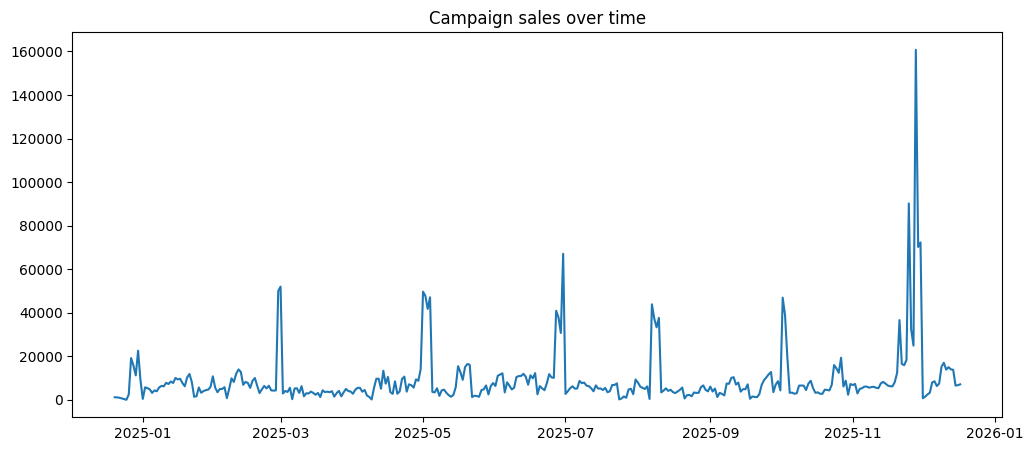

In [6]:
campaign_daily = (
    fact_campaign_sales
    .group_by("sales_date")
    .agg(pl.len().alias("campaign_transactions"))
    .sort("sales_date")
    .collect()
)

plt.figure(figsize=(12,5))
plt.plot(campaign_daily["sales_date"], campaign_daily["campaign_transactions"])
plt.title("Campaign sales over time")
plt.show()

### Points Activity Over Time

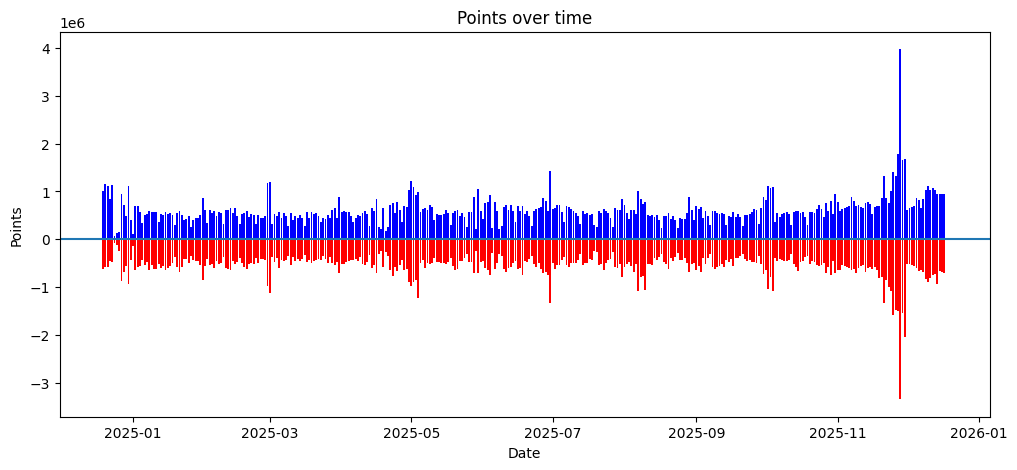

In [7]:
points_daily = (
    fact_points
    .group_by(["point_date","point_type"])
    .agg(pl.sum("points").alias("points"))
    .sort("point_date")
    .collect()
)

colors = ["blue" if p >= 0 else "red" for p in points_daily["points"]]

plt.figure(figsize=(12,5))
plt.bar(points_daily["point_date"], points_daily["points"], color=colors)

plt.axhline(0)  # zero line for clarity
plt.title("Points over time")
plt.xlabel("Date")
plt.ylabel("Points")

plt.show()

### Web Sessions Over Time

In [ ]:
sessions = con.execute("""
SELECT
event_date,
COUNT(*) AS events
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
GROUP BY event_date
ORDER BY event_date
""").pl()

sessions

In [ ]:
sessions = con.execute("""
SELECT
timestamp,
COUNT(*) AS events
FROM '/work/data/parquets/fact_web_sessions_v2.parquet'
GROUP BY timestamp
ORDER BY timestamp
""").pl()

sessions

### Seasonality Check

In [10]:
sales_week = (
    fact_sales
    .with_columns(pl.col("sales_date").dt.truncate("1w").alias("week"))
    .group_by("week")
    .agg(pl.sum("revenue").alias("revenue"))
    .sort("week")
    .collect()
)

### Missing date detection

In [ ]:
dates = (
    fact_sales
    .select(pl.col("sales_date").unique())
    .collect()
)

full_range = pl.date_range(
    start=dates["sales_date"].min(),
    end=dates["sales_date"].max(),
    interval="1d"
)

missing = set(full_range) - set(dates["sales_date"])

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1615b33a-d424-41db-9b01-6976e7db6ad0' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>